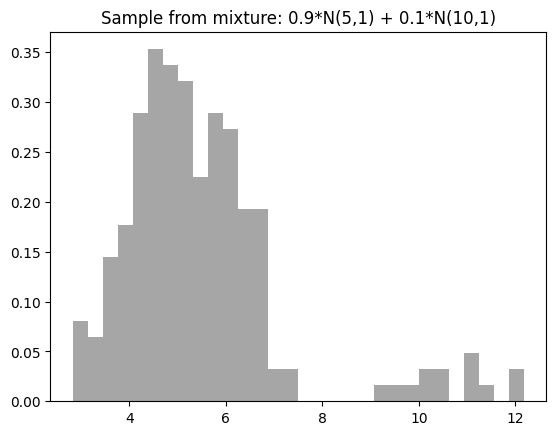

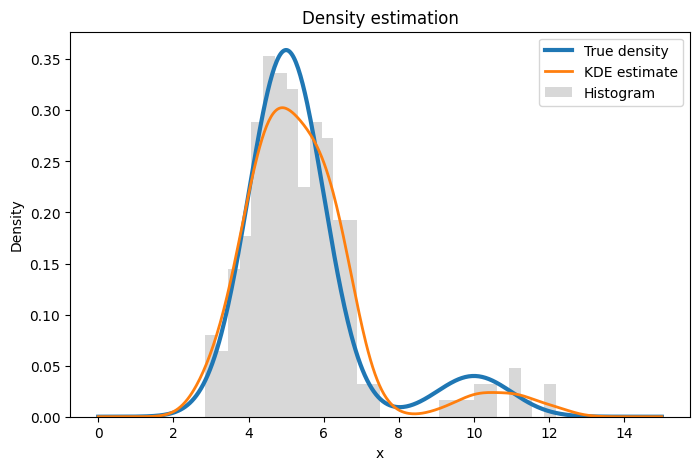

In [1]:
from kde import mse, kde_diff_n, kde_diff_kernels, kde_diff_bandwidths, estimate_bandwidth, sample1, sample2, kde_fitting_mse
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from scipy.stats import norm

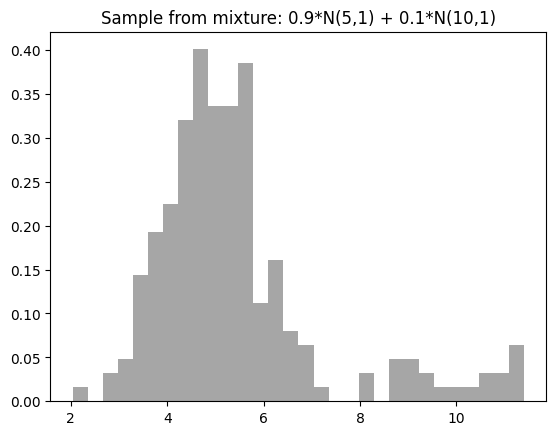

In [2]:
n = 200
cluster = np.random.binomial(1, 0.1, size=n)
x = np.zeros(n)

for i in np.arange(n):
    if cluster[i] == 0:
        x[i] = np.random.normal(loc=5, scale=1, size=1)[0]
    else:
        x[i] = np.random.normal(loc=10, scale=1, size=1)[0]

plt.hist(x, bins=30, density=True, alpha=0.7, color="grey")
plt.title("Sample from mixture: 0.9*N(5,1) + 0.1*N(10,1)")
plt.show()

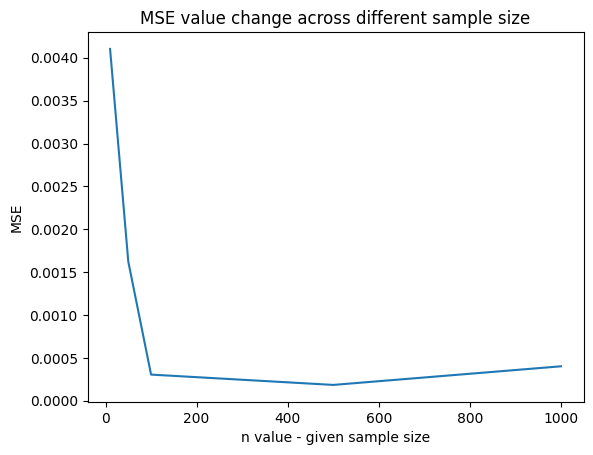

In [3]:
kde_diff_n()

In [4]:
x

array([ 5.61237566,  4.04171007,  4.92765552,  4.37188229,  4.09703762,
        5.4898366 ,  5.40244143, 10.50083267,  5.10118984,  4.7325735 ,
        5.54374449,  3.30375958,  4.63013614,  3.47084718,  4.85235159,
        3.40700169,  9.0396438 ,  4.37949577,  5.47496166,  6.02922656,
        4.76812473,  6.29619531,  4.95597287,  4.86254735,  4.60382453,
        6.1667049 ,  6.42059248,  4.58785156,  3.62736105,  4.24502562,
        4.36629101,  5.63341968,  5.38388174,  4.21249674,  3.4386233 ,
        5.2533432 ,  5.55896631,  8.94300001,  7.99277734,  4.66041326,
        5.56390347,  4.710696  ,  4.73188107,  9.49227759,  4.18152438,
        5.94152166,  6.15430561,  4.58783981,  6.13388399,  5.26850416,
        5.39170988,  5.66286864,  5.30532238,  6.07633115,  4.76057166,
        5.71183703,  3.68431917, 11.25783765,  5.57660246,  5.74317585,
        3.44094311,  4.79176178,  4.88960603,  4.30176232,  3.93192651,
        3.09970844,  5.02853706,  6.23876874,  5.60322013, 11.40

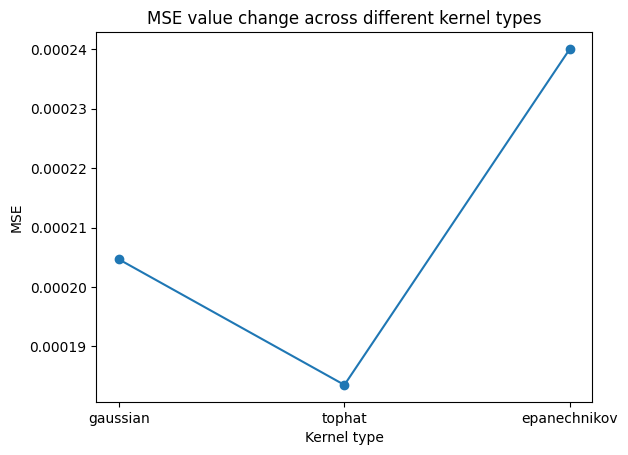

In [5]:
kde_diff_kernels(x=x)

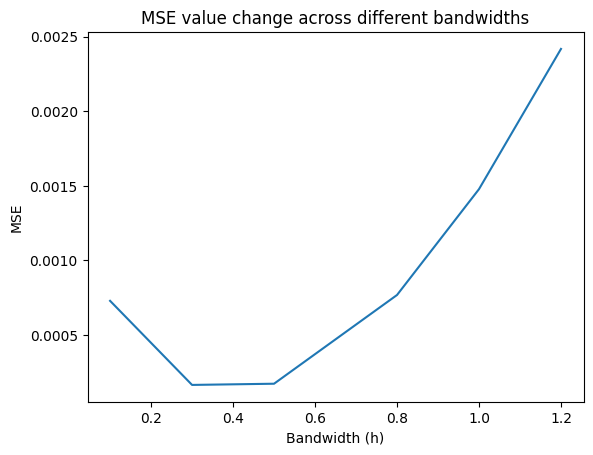

In [6]:
kde_diff_bandwidths(x=x)

In [8]:
est_bandwidth = estimate_bandwidth(x)

Best bandwidth:  0.49999999999999994


In [15]:
est_bandwidth.astype(np.float64)

0.49999999999999994

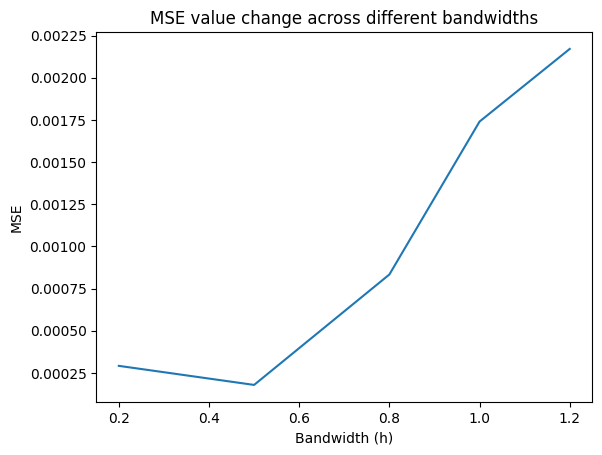

In [16]:
kde_diff_bandwidths(x=x, bandwidth_val=[0.2, est_bandwidth, 0.8, 1.0, 1.2])

Too small bandwidth -> focuses on a small neighbourhood of a point and might result in overfitting<br>
Too large bandwidth -> might result in too big of a generalization

In [4]:
# k = 200
x1 = sample1()
x2 = sample2(x1, k=200)
print(kde_fitting_mse(x1).astype(np.float64))
print(kde_fitting_mse(x2).astype(np.float64))

0.00018678725586255312
0.0006492901877882335


In [8]:
# k = 500
x1 = sample1()
x2 = sample2(x1, k=500)

print(kde_fitting_mse(x1).astype(np.float64))
print(kde_fitting_mse(x2).astype(np.float64))


0.000339900469371422
0.000583100704978331


In [10]:
# k = 1000
x1 = sample1()
x2 = sample2(x1, k=1000)

print(kde_fitting_mse(x1).astype(np.float64))
print(kde_fitting_mse(x2).astype(np.float64))


0.0005256849778628783
0.000693165195519409


In [13]:
# k = 100000
x1 = sample1()
x2 = sample2(x1, k=100000)

print(kde_fitting_mse(x1).astype(np.float64))
print(kde_fitting_mse(x2).astype(np.float64))

0.00019002358516837653
0.0004298752471498176


These two methods are close because the second is an approximation of the first with additional random step.</br>
Method 1 can be a little bit better than method 2 since in method 2 we resample from already generated sample which adds more randomness.<br>
The bigger k is (the bigger the artifical re-sampled sample is), the stabler method 2 is and mse is lower and more similar to mse in method 1.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from nb_modifications import NBGaussianApprox, NBKDE, NBDiscretized
from lda import LDA

In [2]:
data_spam = pd.read_csv("data/Spam.csv")

In [3]:
data_spam.shape

(4601, 58)

In [4]:
data_spam.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [5]:
data_spam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [6]:
data_spam["spam"].value_counts()

spam
0    2788
1    1813
Name: count, dtype: int64

In [7]:
X_spam = data_spam.drop(columns="spam")
y_spam = data_spam["spam"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_spam,
    y_spam,
    train_size=0.7,
    test_size=0.3,
)

In [9]:
nb_gaussian_approx = NBGaussianApprox()
nb_gaussian_approx.fit(X=X_train, y=y_train)
y_pred = nb_gaussian_approx.predict(Xtest=X_test)
acc_nb_gaussian_approx = (y_pred == y_test).mean()
acc_nb_gaussian_approx

/Users/nadiaserafin/projects/data science/sem 1/aml/laby/lab03/nb_modifications.py:64: RuntimeWarning: overflow encountered in exp
  posterior_1 = 1 / (1 + np.exp(-delta))


0.8059377262853005

In [10]:
nb_kde = NBKDE()
nb_kde.fit(X=X_train, y=y_train)
y_pred = nb_kde.predict(Xtest=X_test)
acc_nb_kde = (y_pred == y_test).mean()
acc_nb_kde

/Users/nadiaserafin/projects/data science/sem 1/aml/laby/lab03/nb_modifications.py:140: RuntimeWarning: overflow encountered in exp
  posterior_1 = 1 / (1 + np.exp(-delta))


0.8725561187545257

In [11]:
nb_discretized = NBDiscretized()
nb_discretized.fit(X=X_train, y=y_train)
y_pred = nb_discretized.predict(Xtest=X_test)
acc_nb_discretized = (y_pred == y_test).mean()
acc_nb_discretized

0.7661115133960897

In [12]:
lda = LDA()
lda.fit(X=X_train, y=y_train)
y_pred = lda.predict(Xtest=X_test) 
acc_lda = (y_pred == y_test).mean()
acc_lda

0.8979000724112962